In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
def load_data(filepath, chunksize=100_000, usecols=None):
    chunks = pd.read_csv(filepath, sep="|", low_memory=False, chunksize=chunksize, usecols=usecols)
    return pd.concat(chunks, ignore_index=True)



df = load_data("../data/insurance_data.csv")

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [6]:
df.shape
df.dtypes
df.describe()

,UnderwrittenCoverID,PolicyID,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
std,6.329371e+04,5.290039e+03,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03
min,1.000000e+00,1.400000e+01,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Rebuilt                     641901
Converted                   641901
WrittenOff                  641901
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
VehicleType                    552
make                           552
mmcode                         552
Model                          552
Cylinders                      552
bodytype                       552
kilowatts                      552
NumberOfDoors                  552
VehicleIntroDate               552
cubiccapacity                  552
CapitalOutstanding               2
dtype: int64

In [8]:
df["LossRatio"] = df["TotalClaims"] / df["TotalPremium"]

([0, 1, 2],
 [Text(0, 0, 'Not specified'), Text(1, 0, 'Male'), Text(2, 0, 'Female')])

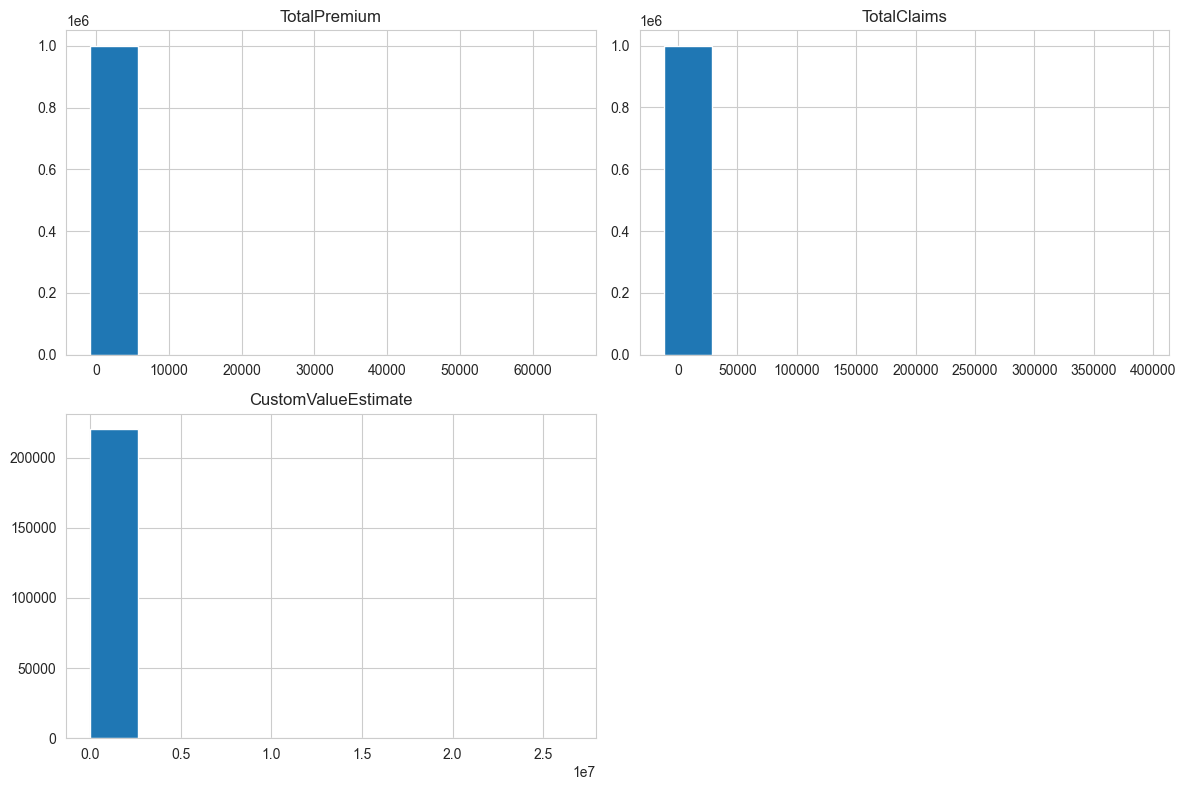

In [9]:
numerical_cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate"
]

df[numerical_cols].hist(figsize=(12,8))
plt.tight_layout()

sns.countplot(data=df, x="Gender")
plt.xticks(rotation=45)

In [ ]:
sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    hue="Province"
)

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

In [ ]:
province_summary = df.groupby("Province")[
    ["TotalPremium", "TotalClaims"]
].mean()

province_summary.plot(kind="bar", figsize=(12,6))

In [ ]:
sns.boxplot(x=df["TotalClaims"])

sns.boxplot(x=df["CustomValueEstimate"])

In [ ]:
df["TransactionMonth"] = pd.to_datetime(df["TransactionMonth"])

monthly_claims = df.groupby(
    df["TransactionMonth"].dt.to_period("M")
)["TotalClaims"].mean()

monthly_claims.plot(figsize=(12,5))

In [ ]:
vehicle_claims = df.groupby("make")["TotalClaims"].mean()

vehicle_claims.sort_values(ascending=False).head(10)

vehicle_claims.sort_values().head(10)

In [ ]:
overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

In [ ]:
pivot = df.pivot_table(
    values="LossRatio",
    index="Province",
    columns="VehicleType",
    aggfunc="mean"
)

sns.heatmap(pivot, cmap="Reds")

monthly_claims.plot(marker="o")

plt.scatter(
    df["TotalPremium"],
    df["TotalClaims"],
    s=df["CustomValueEstimate"]/1000,
    alpha=0.5
)